In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/playground-series-s5e11/sample_submission.csv
/kaggle/input/playground-series-s5e11/train.csv
/kaggle/input/playground-series-s5e11/test.csv


## 1. Import Libraries 

In [2]:
#for data preprocessing 
import pandas as pd
import numpy as np

#FOR DATA PREPROCESSING (SPECIFIC TO ML MODELLING)

#to split data into training data and testing data
from sklearn.model_selection import train_test_split 

#to convert categorical to numerical form
from sklearn.preprocessing import LabelEncoder 


#FOR EVALUATION

#Random Search hyperparameter tuning technique
from sklearn.model_selection import RandomizedSearchCV  
#metric to evaluate how good our classifications are
from sklearn.metrics import roc_auc_score 

## 2. Reading in file 

In [3]:
df = pd.read_csv("/kaggle/input/playground-series-s5e11/train.csv")
df_test = pd.read_csv("/kaggle/input/playground-series-s5e11/test.csv")
df_sub = pd.read_csv("/kaggle/input/playground-series-s5e11/sample_submission.csv")

## 3. Exploratory Data Analysis 

In [4]:
#this looks at first 5 rows 
df.head()

,id,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,grade_subgrade,loan_paid_back
0,0,29367.99,0.084,736,2528.42,13.67,Female,Single,High School,Self-employed,Other,C3,1.0
1,1,22108.02,0.166,636,4593.10,12.92,Male,Married,Master's,Employed,Debt consolidation,D3,0.0
2,2,49566.20,0.097,694,17005.15,9.76,Male,Single,High School,Employed,Debt consolidation,C5,1.0
3,3,46858.25,0.065,533,4682.48,16.10,Female,Single,High School,Employed,Debt consolidation,F1,1.0
4,4,25496.70,0.053,665,12184.43,10.21,Male,Married,High School,Employed,Other,D1,1.0


In [5]:
df_test.head()

,id,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,grade_subgrade
0,593994,28781.05,0.049,626,11461.42,14.73,Female,Single,High School,Employed,Other,D5
1,593995,46626.39,0.093,732,15492.25,12.85,Female,Married,Master's,Employed,Other,C1
2,593996,54954.89,0.367,611,3796.41,13.29,Male,Single,Bachelor's,Employed,Debt consolidation,D1
3,593997,25644.63,0.110,671,6574.30,9.57,Female,Single,Bachelor's,Employed,Debt consolidation,C3
4,593998,25169.64,0.081,688,17696.89,12.80,Female,Married,PhD,Employed,Business,C1


In [6]:
#checking null values for training data 
df.isnull().sum()

id                      0
annual_income           0
debt_to_income_ratio    0
credit_score            0
loan_amount             0
interest_rate           0
gender                  0
marital_status          0
education_level         0
employment_status       0
loan_purpose            0
grade_subgrade          0
loan_paid_back          0
dtype: int64

In [7]:
#checking null values for testing data 
df_test.isnull().sum()

id                      0
annual_income           0
debt_to_income_ratio    0
credit_score            0
loan_amount             0
interest_rate           0
gender                  0
marital_status          0
education_level         0
employment_status       0
loan_purpose            0
grade_subgrade          0
dtype: int64

## 4. Data Preprocessing 

### This includes cleaning the data, assigning X and y etc, encoding categorical variables 

In [8]:
#for training data
X = df.drop(columns = ["loan_paid_back"])
y = df["loan_paid_back"]

In [9]:
#for test data 
X_test_final = df_test

In [10]:
#retrieving categorical columns and numerical columns 

numerical_cols =  df.select_dtypes(include="number").columns.tolist()
categorical_cols = df.select_dtypes(include=['object', 'bool']).columns.tolist()


print(f"categorical columns : {categorical_cols}")
print(f"numerical columns : {numerical_cols}")

categorical columns : ['gender', 'marital_status', 'education_level', 'employment_status', 'loan_purpose', 'grade_subgrade']
numerical columns : ['id', 'annual_income', 'debt_to_income_ratio', 'credit_score', 'loan_amount', 'interest_rate', 'loan_paid_back']


In [11]:
#apply label encoding consistently to both train and test
for col in categorical_cols:
    le = LabelEncoder()
    #fit on combined data to ensure all categories are seen
    combined = pd.concat([X[col], X_test_final[col]], axis=0)
    le.fit(combined)
    X[col] = le.transform(X[col])
    X_test_final[col] = le.transform(X_test_final[col])

What the above code does:
1. Go through all categorical columns.
2. Encode each column into numbers.
3. Fit the encoder on combined train + test data to avoid unseen categories in the test set.
4. Transform both train and test columns into numeric form.

Some Revision: 

pd.concat = combines 2 dataframes together (concatenates them)

* le.fit(y) → learns the mapping from class labels to numbers (e.g., ['cat', 'dog'] → [0, 1]).

* le.transform(y) → converts the labels to numbers using that mapping.

In [12]:
X.head()

,id,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,grade_subgrade
0,0,29367.99,0.084,736,2528.42,13.67,0,2,1,2,6,12
1,1,22108.02,0.166,636,4593.10,12.92,1,1,2,0,2,17
2,2,49566.20,0.097,694,17005.15,9.76,1,2,1,0,2,14
3,3,46858.25,0.065,533,4682.48,16.10,0,2,1,0,2,25
4,4,25496.70,0.053,665,12184.43,10.21,1,1,1,0,6,15


In [13]:
X_test_final.head()

,id,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,grade_subgrade
0,593994,28781.05,0.049,626,11461.42,14.73,0,2,1,0,6,19
1,593995,46626.39,0.093,732,15492.25,12.85,0,1,2,0,6,10
2,593996,54954.89,0.367,611,3796.41,13.29,1,2,0,0,2,15
3,593997,25644.63,0.110,671,6574.30,9.57,0,2,0,0,2,12
4,593998,25169.64,0.081,688,17696.89,12.80,0,1,4,0,0,10


In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
#20 % of the data = testing data, 80% will be training 

## 5. Training the Model

Steps for implementing hyperparameter tuning: 

1. Base model
2. Define parameter search space
       - establishing the range of possible values for each hyperparameter that will be tested
4. Implementing actual hyperparameter method
5. fitting training data 

In [21]:
#our random forest model
from sklearn.ensemble import RandomForestClassifier

#random search hyperparameter tuning technique
from sklearn.model_selection import RandomizedSearchCV

#randint(a,b) selects integer values between a and b 
from scipy.stats import randint 

In [36]:
#Base model 
rf = RandomForestClassifier(
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)
#bootstrap=True enables bootstrap sampling 
#random_state=42 is for reproducibility 
#n_jobs=-1 uses all available CPU cores -> speeds up model fitting

In [37]:
#defining hyperparameter search space
param_dist = {
    "n_estimators": randint(20, 80),     
    "max_depth": randint(3, 15),          # no huge trees 
    "min_samples_split": randint(2, 20),
    "min_samples_leaf": randint(1, 5),
    "max_features": ["sqrt", "log2"],     # fast
}

#### n_estimators (20–80)
    - Number of trees in the forest.
    - Lower range → faster training/evaluation.
    - Too few may underfit; many more increases compute time.
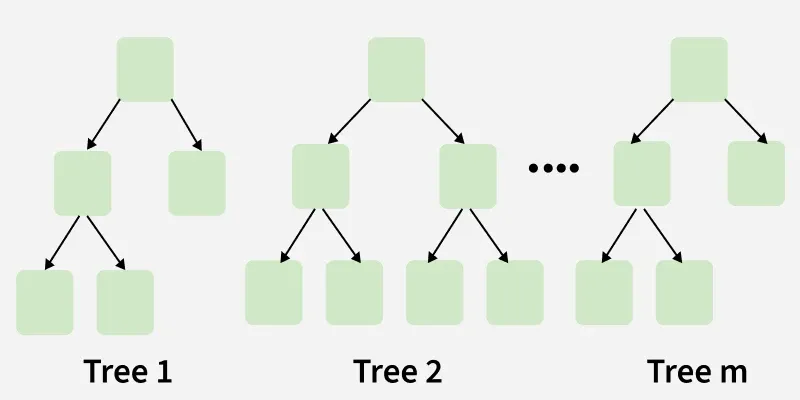

#### max_depth (3–15)
    - Maximum depth a tree can grow to.
    - Prevents extremely deep trees, which reduces overfitting and keeps model fast.
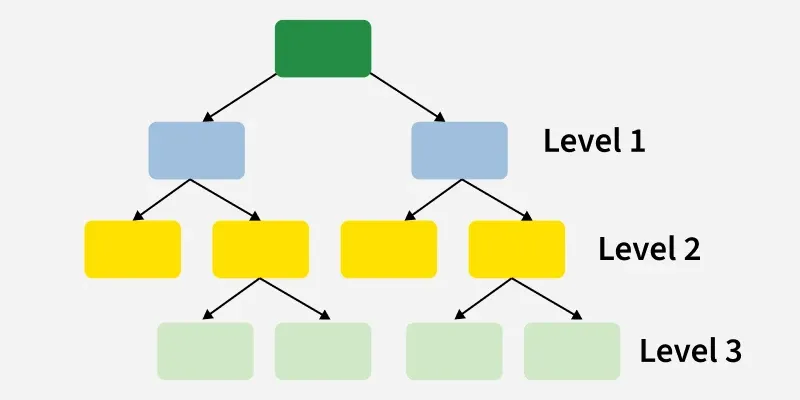

#### min_samples_split (2–20)
    - Minimum number of samples/data points required to split a node.
    - Higher values → fewer splits → simpler trees → less overfitting.

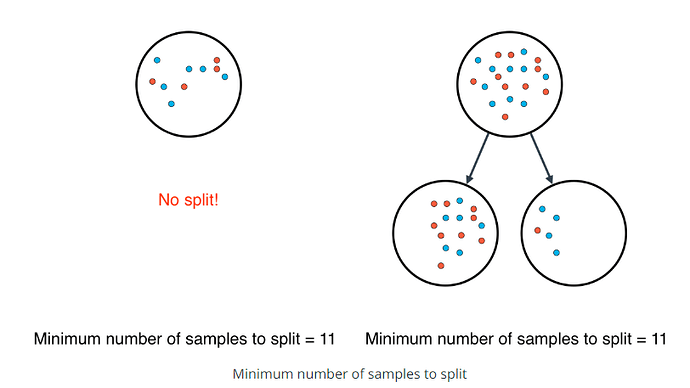

#### min_samples_leaf (1–5)
    - Minimum number of samples/data points required in a leaf node.
    - Larger leaves reduce variance and help generalization.

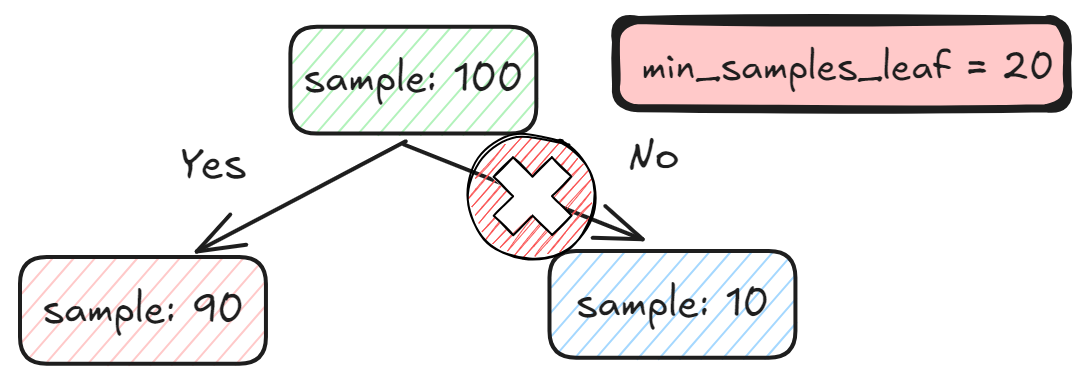![image.png]


#### max_features ("sqrt" or "log2")
    - Number of features considered for each tree
    - "sqrt" and "log2" are both small fractions → much faster splits and reduced overfitting.
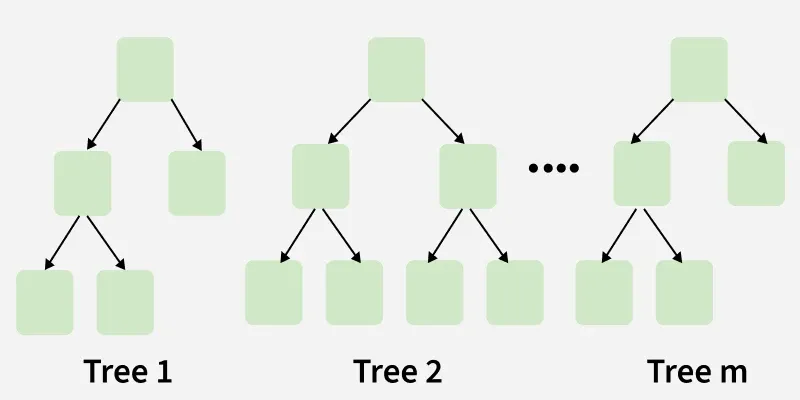
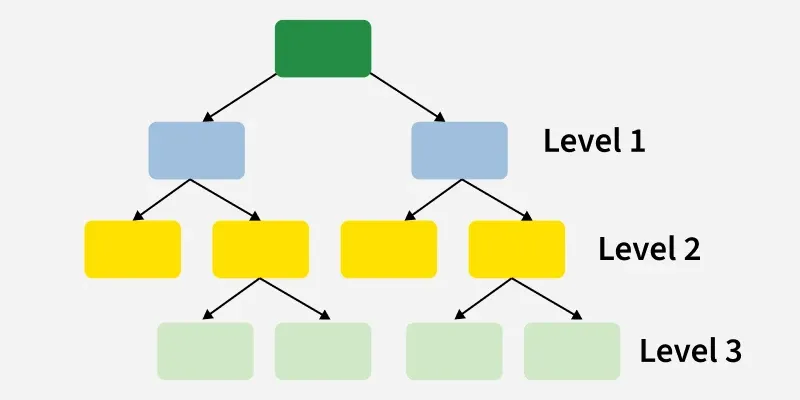
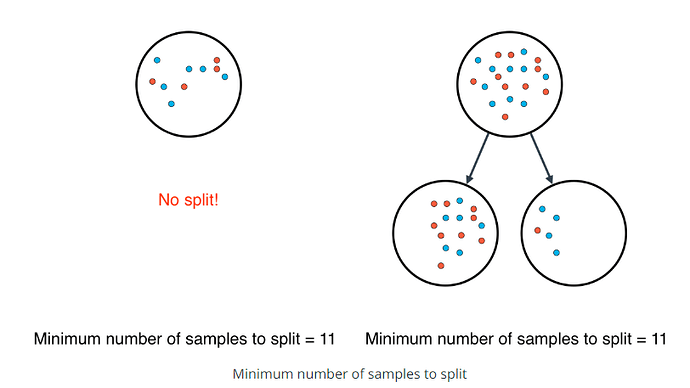
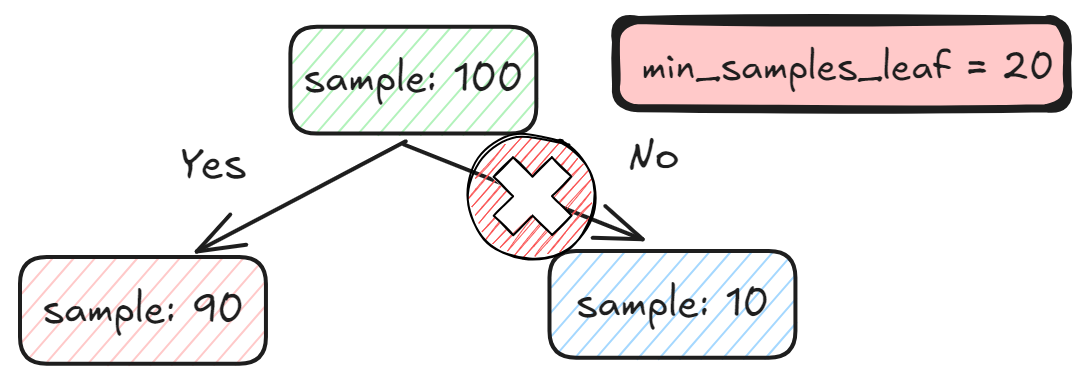

In [38]:
#implementing actual hyperparameter method : Random Search  

search = RandomizedSearchCV(
    estimator=rf,               #This is our Random Forest model 
    param_distributions=param_dist,  #range of hyperparameters we want to try
    n_iter=8,                   # Number of random combinations of hyperparameters to try (smaller = faster)
    cv=2,                        # Number of cross-validation folds (split data into 2 parts for training/testing)
    scoring="roc_auc",           # Metric used to evaluate model performance (ROC AUC in this case)
    random_state=42,             # Fix the random seed so results are reproducible
    n_jobs=-1,                   # Use all available CPU cores to speed up computation
    verbose=1                    # Print progress and info during the search
)

In [39]:
search.fit(X_train, y_train)


print("Best parameters:", search.best_params_)
best_rf = search.best_estimator_

Fitting 2 folds for each of 8 candidates, totalling 16 fits
Best parameters: {'max_depth': 12, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 13, 'n_estimators': 44}


In [40]:
# ----- Predict probabilities -----
y_pred_proba = best_rf.predict_proba(X_test)[:, 1]

# ----- ROC-AUC evaluation -----
auc = roc_auc_score(y_test, y_pred_proba)
print("Test ROC-AUC:", auc)

Test ROC-AUC: 0.9135651812105439


<0.5 - worse than a random classifier 

0.5 - essentially a random classifier 

1 = perfect classifier 

## 6. Final Predictions and Submission + Check!

In [41]:

y_pred_final = best_rf.predict_proba(X_test_final)[:, 1]
# Show first few predictions
print("Sample predictions for X_test:")
print(y_pred_final[:10])

Sample predictions for X_test:
[0.80212974 0.93409671 0.47230125 0.94604534 0.91134755 0.9305755
 0.97316894 0.96929026 0.87293078 0.07014101]


In [42]:
submission = pd.DataFrame({'id': df_sub['id'],'loan_paid_back': y_pred_final})
submission

# Save to CSV
submission.to_csv('submission.csv', index=False)

### You can make this model better! Try different models like LGBM and catboost, different hyperparameters and try to beat this score!